# **Abstract**

The global fitness industry has experienced substantial growth over the past decade, yet it remains unclear whether this expansion has translated into improved public fitness engagement across different regions. This study explores the relationship between the growth of the global fitness market and population-level fitness engagement using the World Gym & Fitness Trends (2000–2026) dataset. The analysis focuses on 1,056 observations from 132 countries between 2019 and 2026, allowing for the examination of post-pandemic trends. Data preprocessing included filtering the dataset by year, verifying the absence of missing values, duplicate records, and invalid numerical entries, as well as categorizing countries based on GDP per capita and average gym membership costs. Exploratory Data Analysis (EDA) was then conducted using descriptive statistics and visualizations to investigate the relationships between fitness engagement indicators (fitness participation rate, gym penetration rate, and insufficient physical activity) and economic and accessibility-related variables, including GDP per capita, health club revenue, gym membership cost, number of gyms, and urban population percentage. The findings suggest that countries with higher gym penetration rates generally exhibit stronger economic performance and larger health club markets. Accessibility-related factors, particularly urban population percentage and the number of gyms, demonstrate stronger associations with fitness participation than membership cost, which showed inconsistent relationships across regions. Furthermore, while the global fitness market exhibited signs of financial recovery and growth following the pandemic, improvements in population fitness engagement remained relatively modest. These results indicate that market expansion alone does not necessarily translate into greater public participation in fitness, emphasizing the importance of accessibility and region-specific socioeconomic factors in shaping health behaviors.

# **Dataset Description**  

The dataset, entitled "**World Gym & Fitness Trends (2000 - 2026)**" contains global data about the fitness industry from 132 countries, as well as relevant  metrics collected per country—namely number of gym memberships, total health club revenue, obesity rate, and more.

The [original dataset](https://www.kaggle.com/datasets/aryanmdev/world-gym-and-fitness-trends-20002026) was obtained from Kaggle, published by user Aryan Mishra. According to the original publisher, the data was collected from multiple sources, including the Health & Fitness Association (HFA), WHO Global Health Observatory, and World Bank Open Data. API extraction, downloadable datasets, and manual compilation from official industry reports were utilized in the collection of data by the original creators.

It is important to note that due to the original data collection method (standardized API data blended with manually compiled reports), there could exist discrepancies and inconsistencies among variables. While programmatic API inputs from the World Bank and WHO provide highly standardized, continuous metrics, the manually compiled PDF reports from industry associations are vulnerable to human reporting errors. Nevertheless, because these industry reports are sourced from authoritative bodies like the Health & Fitness Association and Deloitte, any potential biases remain minimal and are unlikely to distort the bigger picture.

Each row in the dataset corresponds to a single observation which contains per country, per year data. That is, with a year range of 2000-2026, each of the 132 countries included in the dataset has 27 rows—one for each year. In total, there are 3564 observations.

There are a total of 12 non-identifier columns, each corresponding to a variable/metric, present in the dataset. The description of each of these columns are as follows:

1. **Region**: The continent in which the country is located
2. **Gym Memberships**: National index: total recorded number of gym memberships in a country and year
3. **Fitness Participation Rate**: National index: percentage of population who actively engage in fitness activities in a country and year
4. **Total Health Club Revenue (USD)**: Sum of revenue across all health clubs in a country and year
5. **Number of Gyms**: Total count of gyms in a country and year
6. **Gym Penetration Rate**: Gym memberships / population total, i.e. what percentage of the total population has a gym membership (people included here can have more than one membership)?
7. **Urban Population Percentage**: Proportion of the total population that resides in urban spaces
8. **Obesity Rate**: Percentage of the population that is obese: BMI >= 30.0
9. **GDP per Capita (USD)**: Gross domestic product / population total; economic index to be used for a given country and year
10. **Population Total**: Total number of people in a given country and year
11. **Average Membership Cost (USD)**: Mean of health club membership cost in a given country and year
12. **Insufficient Physical Activity**: National index: percentage of population with lack of exercise within certain country and year; there are global minimum standards followed for this (<150 Minutes per week of physical activity is considered insufficient as per [WHO](https://who-dev5.prgsdev.com/m/data/gho/indicator-metadata-registry/imr-details/3416))

# **Data Cleaning and Preprocessing**

The dataset is filtered between years 2019 and 2026 not only for recency, but also to provide contrast to the patterns and changes in the data that happened before and after pandemic.


The code below imports the necessary libraries, including those for data visualization, as well as read the original .csv dataset file in order to filter it to years 2019 to 2026. Moving forward the variable *df* will be used to refer to this filtered dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  matplotlib.ticker import PercentFormatter
from kmeans import KMeans
import warnings

warnings.filterwarnings('ignore', category=FutureWarning, module='kmeans')

raw_df = pd.read_csv('https://raw.githubusercontent.com/YUANQTIE/CSMODEL-MCO1/refs/heads/main/clean_gym_data.csv')

# Limit year range to 2019-2026
df = raw_df[(raw_df.year >= 2019) & (raw_df.year <= 2026)].copy()

Although the dataset description from [Kaggle](https://www.kaggle.com/datasets) states that it was already cleaned, proper precautions were still exercised to ensure data cleanliness.

The code below checks the general information of each column in the dataset, as well as counts the number of instances of missing values per column.

In [2]:
# Generate general information per column
print(df.info())
print("------------------------------------------------------------------")

# Count instances of missing values per column
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 1056 entries, 19 to 3563
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   country                             1056 non-null   object 
 1   year                                1056 non-null   int64  
 2   region                              1056 non-null   object 
 3   gym_memberships                     1056 non-null   int64  
 4   fitness_participation_rate          1056 non-null   float64
 5   total_health_club_revenue_usd       1056 non-null   int64  
 6   number_of_gyms                      1056 non-null   int64  
 7   gym_penetration_rate                1056 non-null   float64
 8   urban_population_percentage         1056 non-null   float64
 9   obesity_rate                        1056 non-null   float64
 10  gdp_per_capita_usd                  1056 non-null   float64
 11  population_total                    1056 non-nu

As per the result above, we can say that there are no missing values present in the dataset. However there is still a possibility of duplicate values and missing values that are represented in a different way. To verify this, the code below does the following:







*   Check for unique values per non-numerical column
*   Check for infinity values per numerical column
*   Generate summary statistics per numerical column





In [3]:
# Check for unique values per non-numerical column

print(df['country'].unique())
print("------------------------------------------------------------------")
print(df['region'].unique())

['Angola' 'Albania' 'United Arab Emirates' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Belgium' 'Benin' 'Burkina Faso'
 'Bangladesh' 'Bulgaria' 'Bahrain' 'Bosnia and Herzegovina' 'Bolivia'
 'Brazil' 'Botswana' 'Canada' 'Switzerland' 'Chile' 'China'
 "Côte d'Ivoire" 'Cameroon' 'Colombia' 'Costa Rica' 'Cyprus'
 'Czech Republic' 'Germany' 'Denmark' 'Dominican Republic' 'Algeria'
 'Ecuador' 'Egypt' 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'United Kingdom' 'Georgia' 'Ghana' 'Greece' 'Guatemala' 'Guyana'
 'Honduras' 'Croatia' 'Hungary' 'Indonesia' 'India' 'Ireland' 'Iran'
 'Iraq' 'Iceland' 'Israel' 'Italy' 'Jamaica' 'Jordan' 'Japan' 'Kazakhstan'
 'Kenya' 'Cambodia' 'South Korea' 'Kuwait' 'Laos' 'Lebanon' 'Sri Lanka'
 'Lithuania' 'Luxembourg' 'Latvia' 'Morocco' 'Moldova, Republic of'
 'Madagascar' 'Mexico' 'North Macedonia' 'Mali' 'Malta' 'Myanmar'
 'Montenegro' 'Mongolia' 'Mozambique' 'Mauritius' 'Malawi' 'Malaysia'
 'Namibia' 'Niger' 'Nigeria' 'Nicaragua' 'Neth

In [4]:
# Check for infinity values per numerical column

print(np.isinf(df['year']).sum())
print(np.isinf(df['gym_memberships']).sum())
print(np.isinf(df['fitness_participation_rate']).sum())
print(np.isinf(df['total_health_club_revenue_usd']).sum())
print(np.isinf(df['number_of_gyms']).sum())
print(np.isinf(df['gym_penetration_rate']).sum())
print(np.isinf(df['urban_population_percentage']).sum())
print(np.isinf(df['obesity_rate']).sum())
print(np.isinf(df['gdp_per_capita_usd']).sum())
print(np.isinf(df['population_total']).sum())
print(np.isinf(df['average_membership_cost_usd']).sum())
print(np.isinf(df['insufficient_physical_activity_pct']).sum())



0
0
0
0
0
0
0
0
0
0
0
0


In [5]:
# Generate summary statistics per numerical column
print(df.describe())

              year  gym_memberships  fitness_participation_rate  \
count  1056.000000     1.056000e+03                 1056.000000   
mean   2022.500000     3.403035e+06                    0.404204   
std       2.292374     9.718611e+06                    0.094094   
min    2019.000000     8.232000e+03                    0.207300   
25%    2020.750000     2.860332e+05                    0.333375   
50%    2022.500000     8.089290e+05                    0.403100   
75%    2024.250000     2.468434e+06                    0.452850   
max    2026.000000     1.027881e+08                    0.675800   

       total_health_club_revenue_usd  number_of_gyms  gym_penetration_rate  \
count                   1.056000e+03     1056.000000           1056.000000   
mean                    9.440324e+08     2865.714015              0.090290   
std                     4.562258e+09     6860.168234              0.068249   
min                     8.336920e+05        9.000000              0.002900   
25%   

Despite the checks, there may still be a possibility of duplicate rows. As such the code below deletes duplicate rows, which is defined as rows with matching values in all columns.

In [6]:
df.drop_duplicates(inplace=True)

As per the results above, there are no duplicate values, nor is there any substantial evidence of the use of sentinel values. As such, it is safe to say that the dataset is now cleaned.

To easily distinguish and categorize a country's wealth, binning will be used in the column *gdp_per_capita_usd* by the following ranges:


*   Less than 5,000
*   5,000 to 20,000
*   20,000 to 50,000
*   Greater than 50,000

Similarly, the same is done to the membership costs, where the column *average_membership_cost_usd* will also be binned by the following ranges:

*   Less than or equal to 5
*   More than 5 to 10
*   More than 10 to 15
*   More than 15 to 50
*   Greater than 50

The code below is executed to achieve the aforementioned binning.

In [7]:
# define the ranges and their respective labels
bin_edges1 = [0, 5000, 20000, 50000, np.inf]
bin_labels1 = ['< $5k', '$5k - $20k', '$20k - $50k', '> $50k']
bin_edges2 = [0, 5, 10, 15, 50, np.inf]
bin_labels2 = ['=< $5', '$5 - $10', '$10 - $15', '$15 - $50', '> $50']

# binning
df['gdp_bins'] = pd.cut(df['gdp_per_capita_usd'], bins=bin_edges1, labels=bin_labels1)
df['cost_bins'] = pd.cut(df['average_membership_cost_usd'], bins=bin_edges2, labels=bin_labels2)

The dataset is now ready for analysis.

# **Research Question & Exploratory Data Analysis**

## **<u>How aligned are the actual public fitness engagement outcomes with the growth of the global fitness market?</u>** ##

### **EDA Question 1: What could be the economical implications of fitness engagement for a country?**

> Before further investigation on how the current conditions of fitness engagement pair with the current fitness market, it is pertinent to consider what could be the economic implications of fitness engagement for a country.

> In the context of this question, fitness will be examined as an amenity. As the providers of fitness services, health clubs represent an economic market wherein consumers purchase memberships in exchange for benefits.

> Like any market, this exchange generates economic activity. Increased fitness engagement may stimulate demand for health club services, generating revenue and profit within the fitness industry while potentially improving population productivity.

These graphs utilize scatter plots with fitted lines of best fit to further illustrate the relationships between gym penetration rate and the economic indicators of GDP per capita and total health club revenue. Outliers in the data are handled here through the use of an IQR interval to provide a better and less noisy illustration. The gym penetration rate is used to highlight the proportion of the population that has access to structured fitness services, while both GDP Per Capita were used as the economic indicator to be used for national scaling.  



#### **Correlating Gym Population of a Continent to Economic Standing**

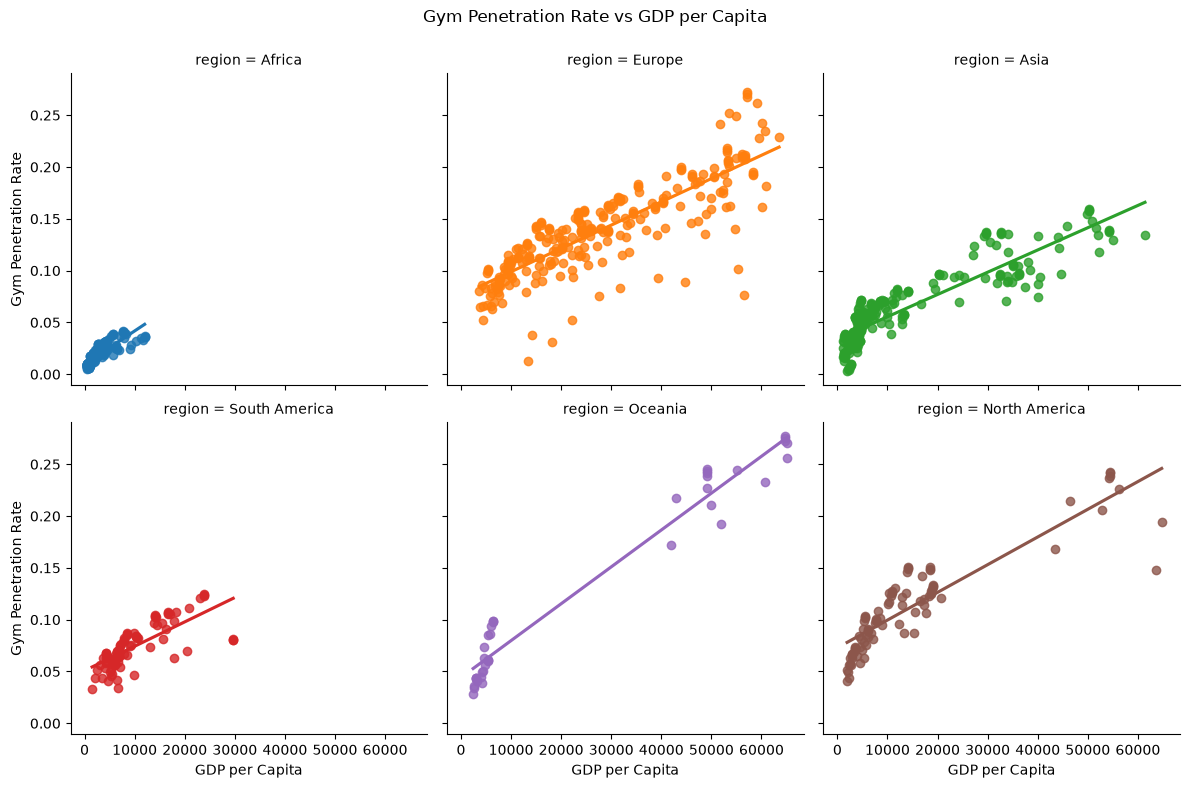

In [8]:
## Gym Penetration Rate vs GDP Per Capita

q1 = df["gdp_per_capita_usd"].quantile(0.25)
q3 = df["gdp_per_capita_usd"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["gdp_per_capita_usd"] >= q1 - 1.5 * iqr) &
    (df["gdp_per_capita_usd"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="gdp_per_capita_usd",
    y="gym_penetration_rate",
    col="region",
    hue="region",
    col_wrap=3,
    ci=None,
    height=4,
    aspect=1
)

plots.set_axis_labels("GDP per Capita", "Gym Penetration Rate")
plt.subplots_adjust(top=0.9)
plots.fig.suptitle("Gym Penetration Rate vs GDP per Capita")
plt.show()

In the first set of plots, it would appear that there would be a positive relationship between gym penetration rates and the economic indicators of both GDP per capita and total health club revenue for all of the regions. From these observations, it may be inferred that countries with higher gym penetration rates tend to exhibit stronger economic conditions and larger fitness markets.



#### **Correlating Positive Fitness Engagement to Economic Standing**


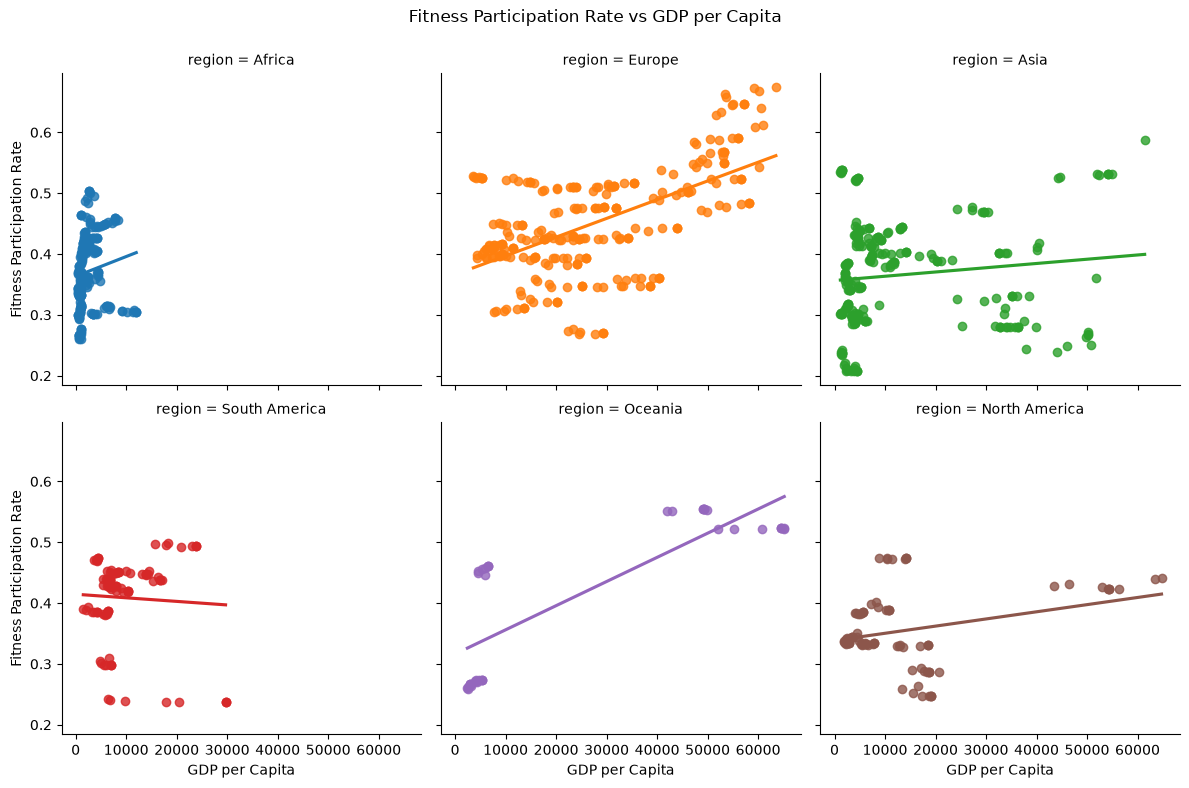

In [9]:
## Fitness Participation vs GDP Per Capita

q1 = df["gdp_per_capita_usd"].quantile(0.25)
q3 = df["gdp_per_capita_usd"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["gdp_per_capita_usd"] >= q1 - 1.5 * iqr) &
    (df["gdp_per_capita_usd"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="gdp_per_capita_usd",
    y="fitness_participation_rate",
    col="region",
    hue="region",
    col_wrap=3,
    ci=None,
    height=4,
    aspect=1
)

plots.set_axis_labels("GDP per Capita", "Fitness Participation Rate")
plt.subplots_adjust(top=0.9)
plots.fig.suptitle("Fitness Participation Rate vs GDP per Capita")
plt.show()

Meanwhile, the 2nd set of graphs would showcase a less unified relationships among the continents. This could possibly be due to fitness participation outside of gyms being more variated and flexible. A scenario would be workouts or exercises done outside of health clubs. Due to these acts being free, this could possibly explain why there is no direct relationship in the 2nd plot.

### **EDA Question 2: What factors affect the fitness participation of a population?**


> Now that we have established the possible relationships between fitness engagement and the economy of a country, it would be optimal to next determine what factors would affect the fitness participation of a population. From the previous graphs, we have inferred that there may be a possible chance of a direct correlation between fitness engagement and the economy of a country. From the dataset we have, we have identified two possible perspectives to look through:

1. Economically
2. Accessibility-Wise

#### **Economic Parameters: Cost of Service**


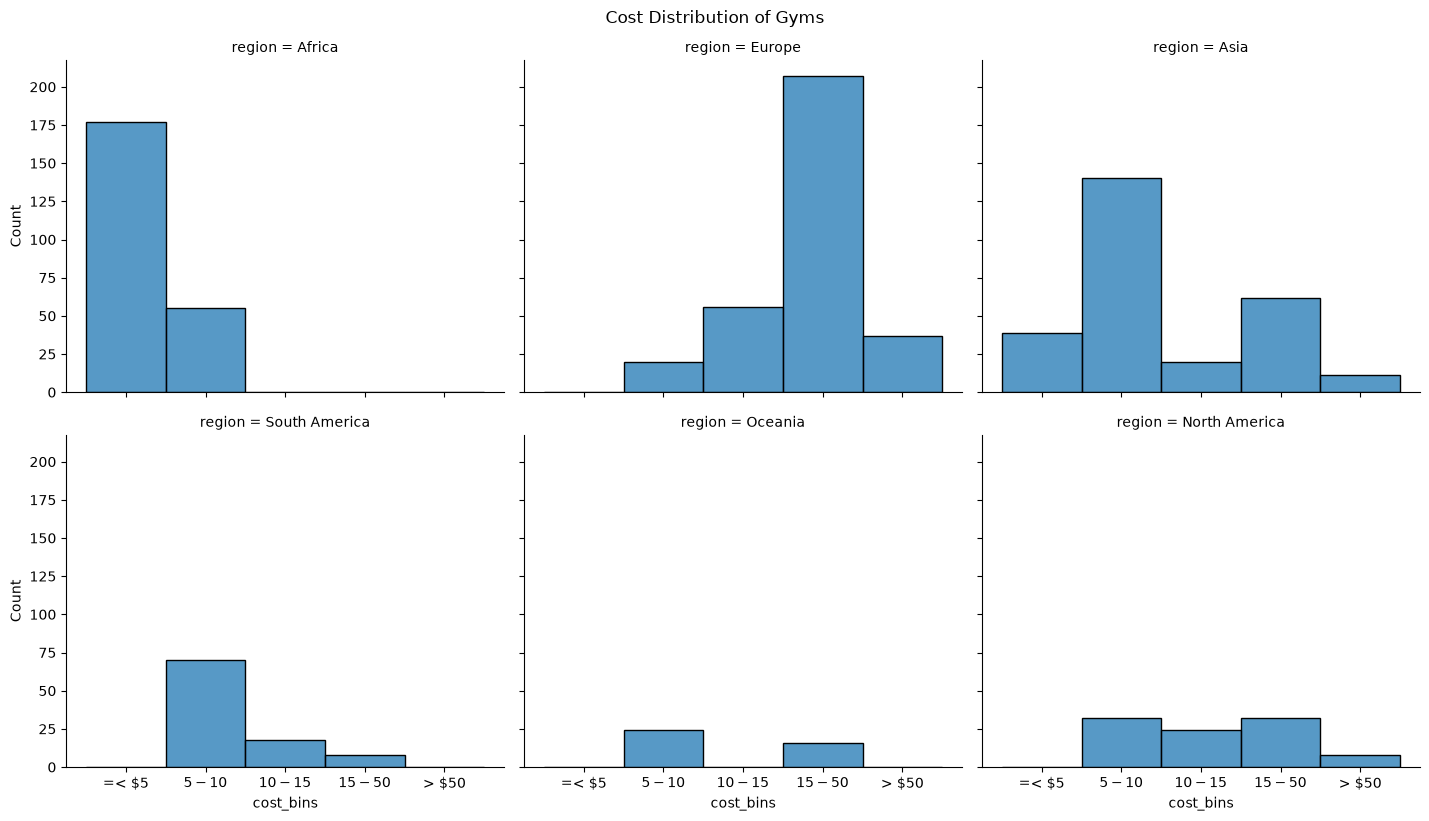

In [10]:
# Illustration of s

sns.displot(
    data=df,
    x="cost_bins",
    col="region",
    bins=15,
    col_wrap=3,
    height=4,
    aspect=1.2
)

plt.suptitle("Cost Distribution of Gyms", y=1.02)
plt.show()

In this plot, we see a bar graph that shows the spread of countries according to the average price of gym memberships there per region. Africa seems to have had cheapest gym memberships, while Europe seems to have the most expensive.

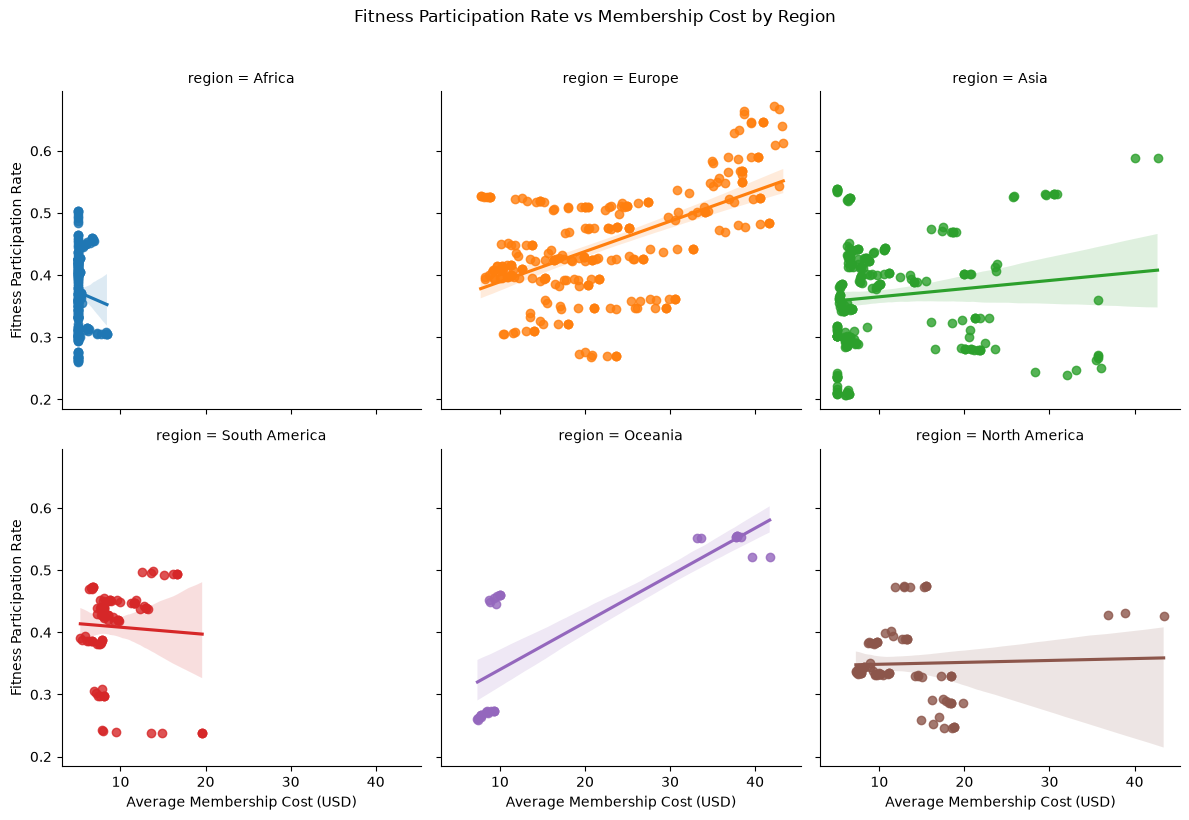

In [11]:
# Fitness Participation Rate vs Membership Cost by Region

q1 = df["average_membership_cost_usd"].quantile(0.25)
q3 = df["average_membership_cost_usd"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["average_membership_cost_usd"] >= q1 - 1.5 * iqr) &
    (df["average_membership_cost_usd"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="average_membership_cost_usd",
    y="fitness_participation_rate",
    col="region",
    hue="region",
    col_wrap=3,
    height=4,
    aspect=1
)

plots.set_axis_labels("Average Membership Cost (USD)", "Fitness Participation Rate")
plots.fig.suptitle("Fitness Participation Rate vs Membership Cost by Region", y=1.02)
plt.tight_layout()
plt.show()

In this plot, we see the correlations between the fitness participation rate and the average membership costs for a club per region. As seen, there is no unified correlation for all of the continents. This could denote that context must be continent-specific.

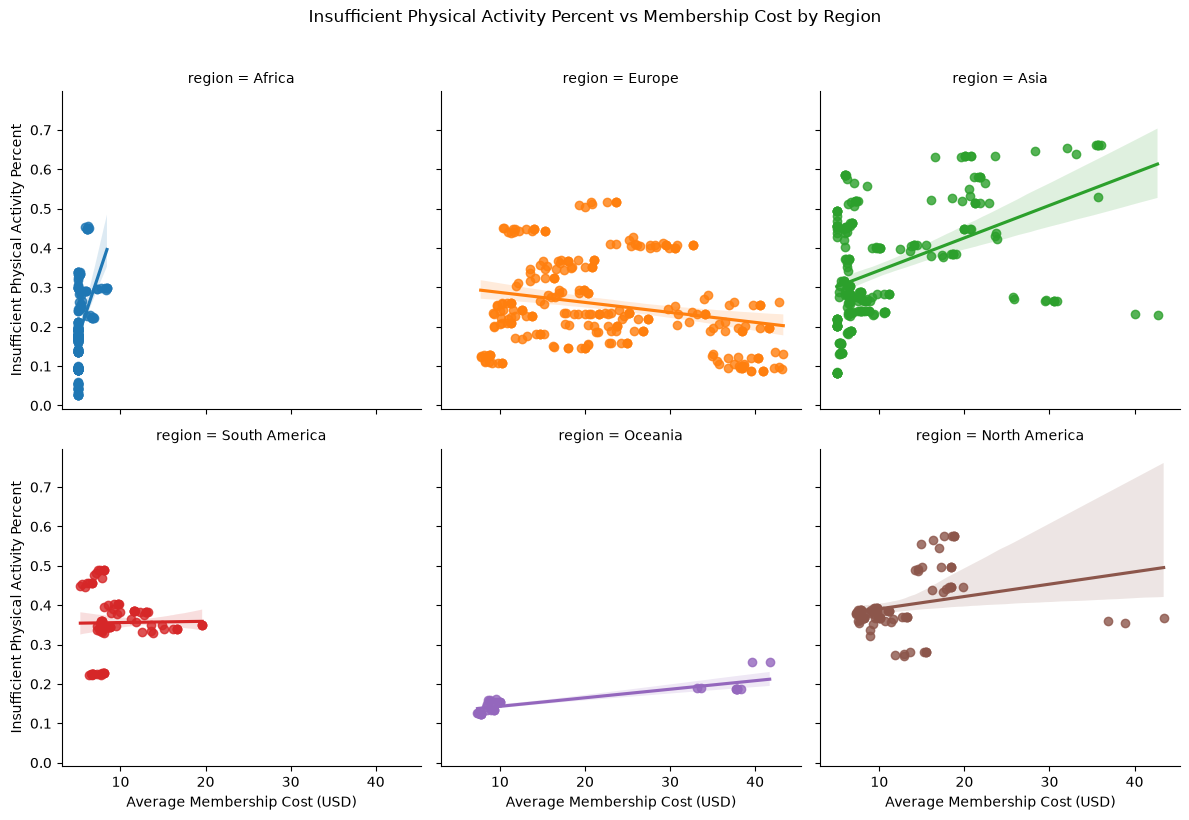

In [12]:
# Insufficient Physical Activity Percent vs Membership Cost by Region

q1 = df["average_membership_cost_usd"].quantile(0.25)
q3 = df["average_membership_cost_usd"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["average_membership_cost_usd"] >= q1 - 1.5 * iqr) &
    (df["average_membership_cost_usd"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="average_membership_cost_usd",
    y="insufficient_physical_activity_pct",
    col="region",
    hue="region",
    col_wrap=3,
    height=4,
    aspect=1
)

plots.set_axis_labels("Average Membership Cost (USD)", "Insufficient Physical Activity Percent")
plots.fig.suptitle("Insufficient Physical Activity Percent vs Membership Cost by Region", y=1.02)
plt.tight_layout()
plt.show()

Similar to the previous graph, there is also no unified correlations for all of the continents. Once again, a possible exploration idea would be a deeper dive into the context per continent.

#### **Accessibility-Driven Parameters: Number of Gyms and Urbanization**


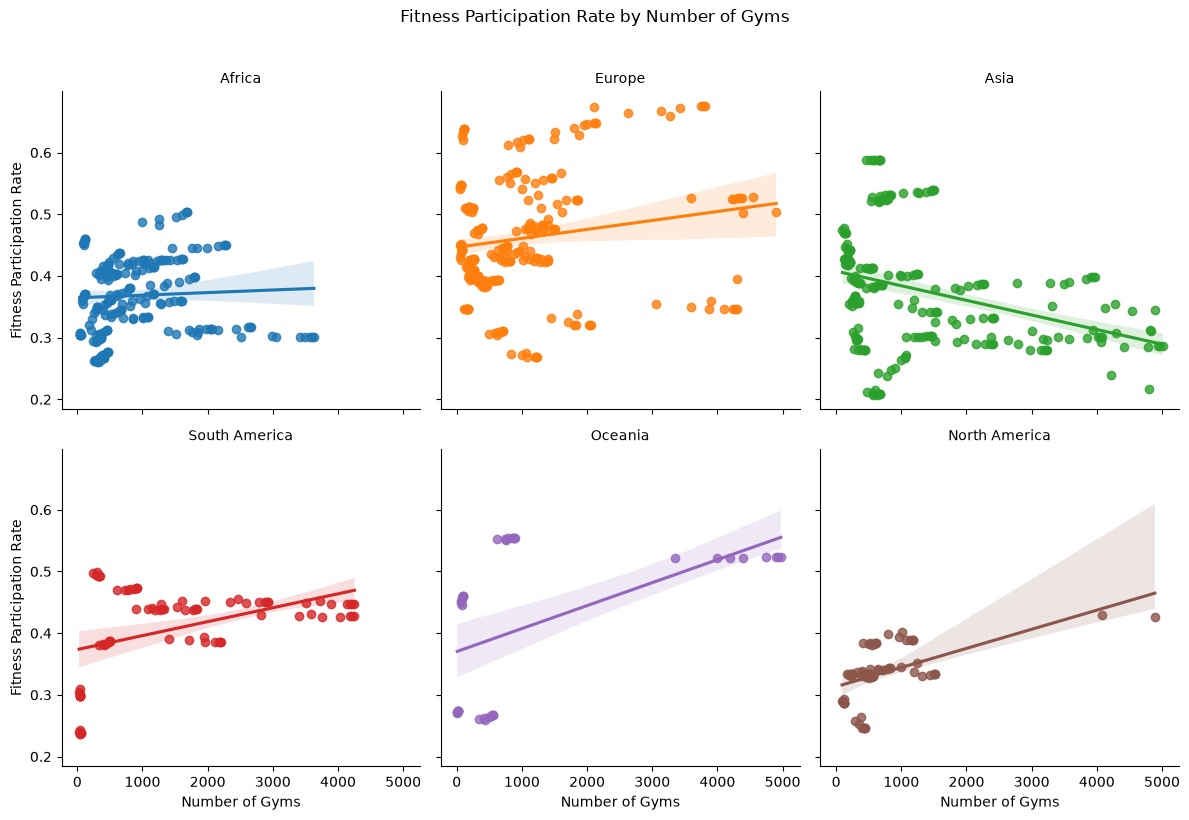

In [13]:
# Fitness Participation Rate by Number of Gyms

q1 = df["number_of_gyms"].quantile(0.25)
q3 = df["number_of_gyms"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["number_of_gyms"] >= q1 - 1.5 * iqr) &
    (df["number_of_gyms"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="number_of_gyms",
    y="fitness_participation_rate",
    col="region",
    hue="region",
    col_wrap=3,
    height=4,
    aspect=1
)

plots.set_axis_labels("Number of Gyms", "Fitness Participation Rate")
plots.set_titles("{col_name}")
plots.fig.suptitle("Fitness Participation Rate by Number of Gyms", y=1.02)
plt.tight_layout()
plt.show()



The first plot shows the correlation between the fitness participation rate and the number of gyms. All of the continents except Asia show having higher fitness participation rates as the number of gyms increase. Of course, more facilities for fitness could most likely encourage a population to be more active. Interestingly, there is less of a unison between the Insufficient Physical Activity % and the number of gyms. Data for Europe and North America seem to show naively accurate information, as the number of gyms could incentivize people more allowing for insufficient physical activity percentages to decrease.

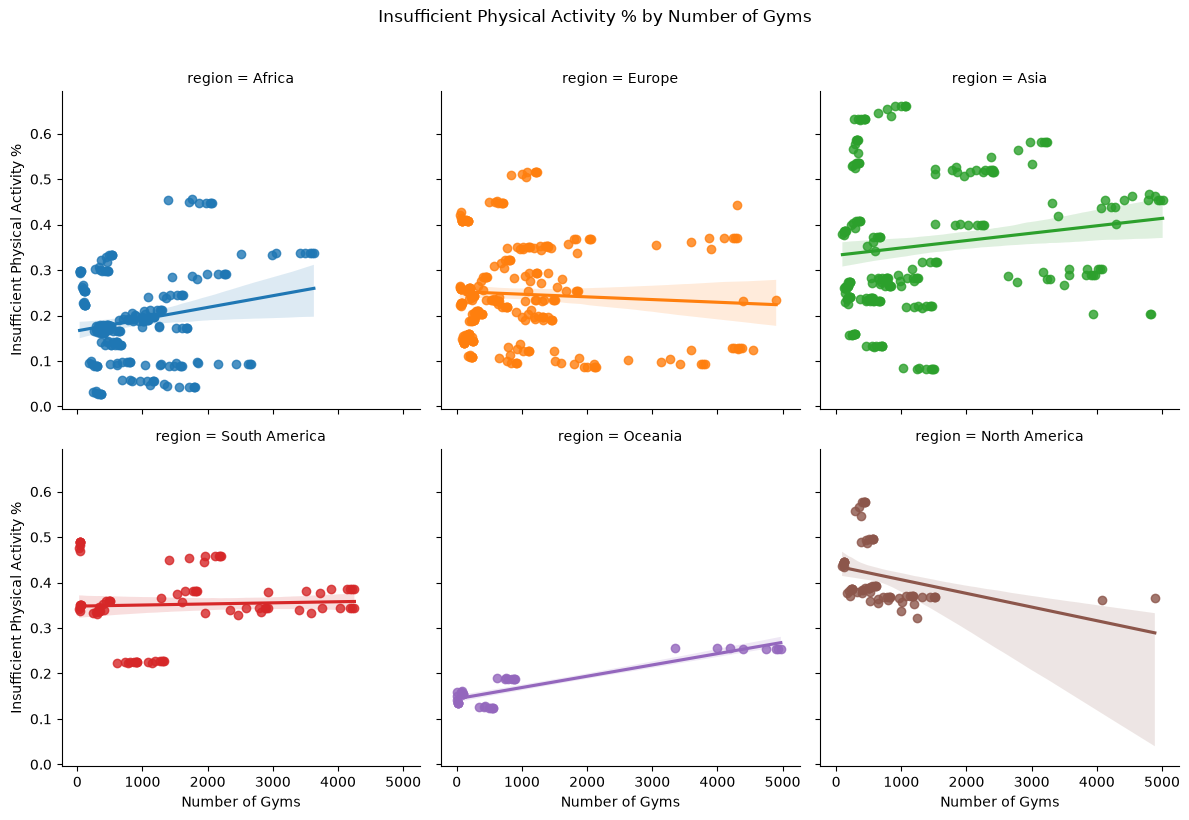

In [14]:
# Insufficient Physical Activity % by Number of Gyms

q1 = df["number_of_gyms"].quantile(0.25)
q3 = df["number_of_gyms"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["number_of_gyms"] >= q1 - 1.5 * iqr) &
    (df["number_of_gyms"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="number_of_gyms",
    y="insufficient_physical_activity_pct",
    col="region",
    hue="region",
    col_wrap=3,
    height=4,
    aspect=1
)

plots.set_axis_labels("Number of Gyms", "Insufficient Physical Activity %")
plots.fig.suptitle("Insufficient Physical Activity % by Number of Gyms", y=1.02)
plt.tight_layout()
plt.show()

From these plots, there is no apparent observable correlation between the costs for a club membership and a population's fitness engagement that would fit every country. The naive assumption would be that if average membership costs were to increase, the fitness participation metric would decrease while insufficient physical activity percent would increase as services will get more expensive. This assumption for now can only be Africa and South America. The other continents' populations seem to be not have gym prices as a consideration for their fitness engagements.

#### **Accessibility-Driven Parameters: Fitness Engagement by Urban Population %**

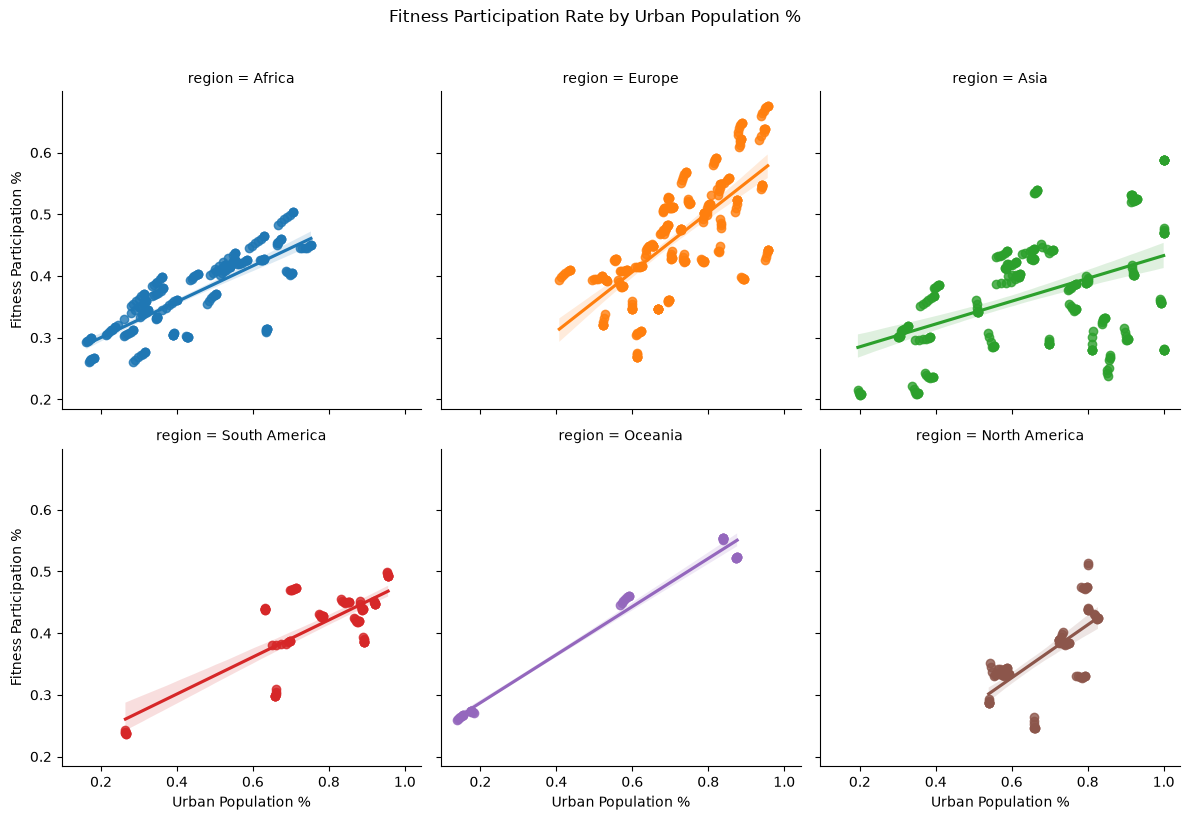

In [15]:
# Fitness Participation by Urban Population %

q1 = df["urban_population_percentage"].quantile(0.25)
q3 = df["urban_population_percentage"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["urban_population_percentage"] >= q1 - 1.5 * iqr) &
    (df["urban_population_percentage"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="urban_population_percentage",
    y="fitness_participation_rate",
    col="region",
    hue="region",
    col_wrap=3,
    height=4,
    aspect=1
)

plots.set_axis_labels("Urban Population %", "Fitness Participation %")
plots.fig.suptitle("Fitness Participation Rate by Urban Population %", y=1.02)
plt.tight_layout()
plt.show()

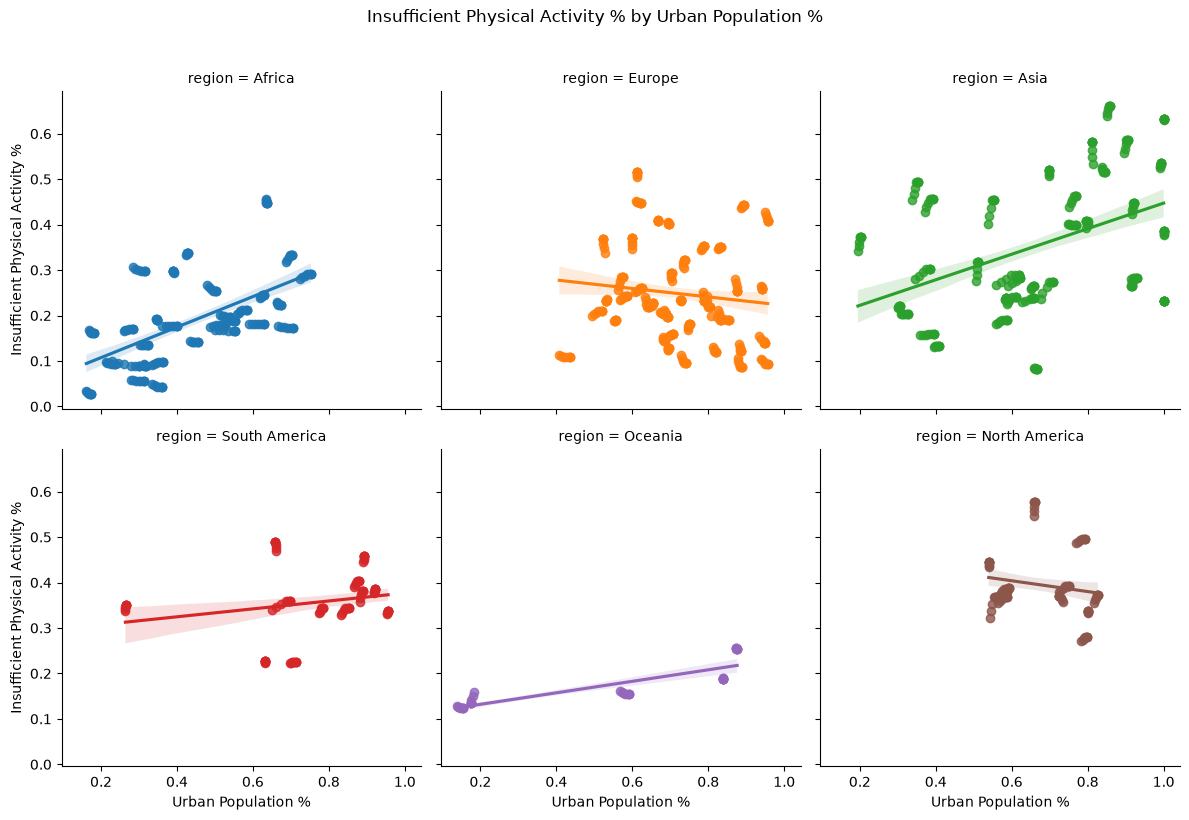

In [16]:
# Insufficient Physical Activity % by Urban Population %

q1 = df["urban_population_percentage"].quantile(0.25)
q3 = df["urban_population_percentage"].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df["urban_population_percentage"] >= q1 - 1.5 * iqr) &
    (df["urban_population_percentage"] <= q3 + 1.5 * iqr)
]

plots = sns.lmplot(
    data=filtered_df,
    x="urban_population_percentage",
    y="insufficient_physical_activity_pct",
    col="region",
    hue="region",
    col_wrap=3,
    height=4,
    aspect=1
)

plots.set_axis_labels("Urban Population %", "Insufficient Physical Activity %")
plots.fig.suptitle("Insufficient Physical Activity % by Urban Population %", y=1.02)
plt.tight_layout()
plt.show()

From these plots, the most notable consideration would be the high observable correlation between fitness participation rate and urban population percentage. This could be attributed to how most gyms and health centers are in urban areas  The social aspects of fitness as well could be well-attributed to the compactness and people-oriented style of living in a metropolitan area.

The next thing to consider here would be inconsistency shown between the insufficient physical activity percentage and the urban population percentage. Most regression lines do still seem to follow an upward trend, but North America and Europe seem to follow a downward trend. That being said, the contrasting results in this graph could lead to more valuable insights regarding continent-specific cultures and behaviors between urban populations and fitness.

Overall, this section showed the variability of motivations for a population's engagement in fitness. The strong direct correlation from the regional graphs would be the fitness participation rate by urban population percentage. This could be attributed to how most activities related to fitness are social, which is amplified in more densely populated, compact, and urban spaces. However, for the other relationships, further context-finding and exploration must be employed to explain why such correlation, or their lack thereof, exist.

### **EDA Question 3:  How does the current trajectory of the global fitness market compare with the current trajectory of regional fitness engagement?**

> This segment of the EDA fully explores the alignment of the regional fitness engagements with the global fitness market. The global fitness market was quantified here through the measuring gym penetration rates and the mean of total health club revenues. Doing this allows for a comparison trends between the fitness engagement metrics with trends in the fitness market, both in terms of financial performance and consumer base. In this part of the EDA, a deeper understanding for the economic conditions of countries will also be drawn to hopefully bring out context as to how these trajectories occur.

#### **Fitness Engagement over the Years**




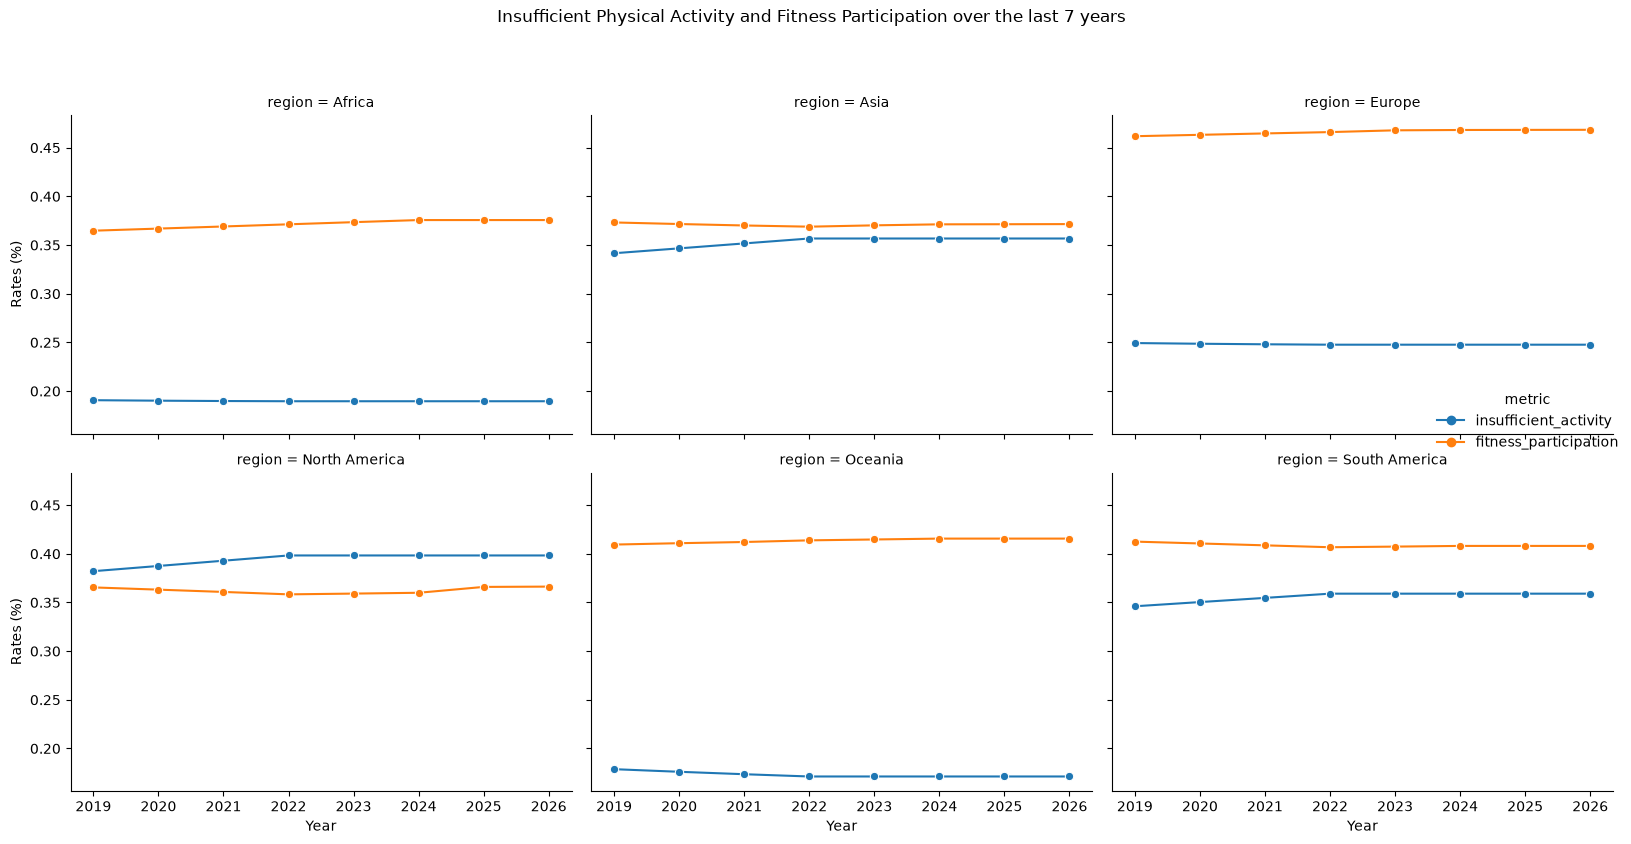

In [17]:
# Insufficient Physical Activity and Fitness Participation over the last 7 years

regional_yearly_summary = (
    df.groupby(["region", "year"])
    .agg(
        insufficient_activity=("insufficient_physical_activity_pct", "mean"),
        fitness_participation=("fitness_participation_rate", "mean"),
    )
    .reset_index()
)

fpr_long = regional_yearly_summary.melt(
    id_vars=["region", "year"],
    value_vars=["insufficient_activity", "fitness_participation"],
    var_name="metric",
    value_name="rate",
)

g = sns.relplot(
    data=fpr_long,
    x="year",
    y="rate",
    col="region",
    col_wrap=3,
    kind="line",
    hue="metric",
    marker="o",
    height=4,
    aspect=1.2,
    legend="auto",
)

g.set_axis_labels("Year", "Rates (%)")

g.figure.suptitle(
    "Insufficient Physical Activity and Fitness Participation over the last 7 years",
    y=1.05,
)

plt.tight_layout()
plt.show()

In this set of plots, we observe that are only minimal growth trends for all 6 regions. This would denote that no notable development has occurred for fitness engagement over the years.



#### **Health Club Finances over the Years**

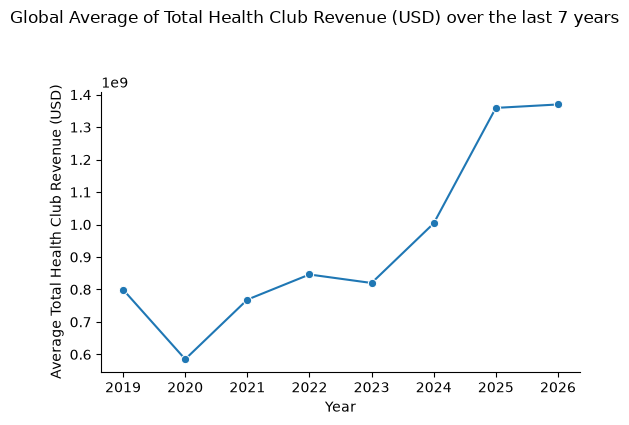

In [18]:
# Global Average of Total Health Club Revenues (USD) the last 7 years

revenue_yearly = (
    df.groupby('year')['total_health_club_revenue_usd']
      .mean()
      .reset_index()
)

g = sns.relplot(
    data=revenue_yearly,
    x='year',
    y='total_health_club_revenue_usd',
    kind='line',
    marker='o',
    height=4,
    aspect=1.4,
)

g.set_axis_labels(
    "Year",
    "Average Total Health Club Revenue (USD)"
)

g.figure.suptitle(
    "Global Average of Total Health Club Revenue (USD) over the last 7 years",
    y=1.05,
)

plt.tight_layout()

plt.show()

On the other hand, this graph illustrates the fall and then the rise of the health club revenues. There is a notable drop from the year 2019-2020, which could be explained by the pandemic's occurrence during that time frame. However, from then on, we see a rise and then a massive boom from 2024-2025. Although this explained by an expansion in user base for gyms, it could also allude to higher prices due to the relevant rises in inflation as well.

#### **Gym Attendance per Population over the Years**

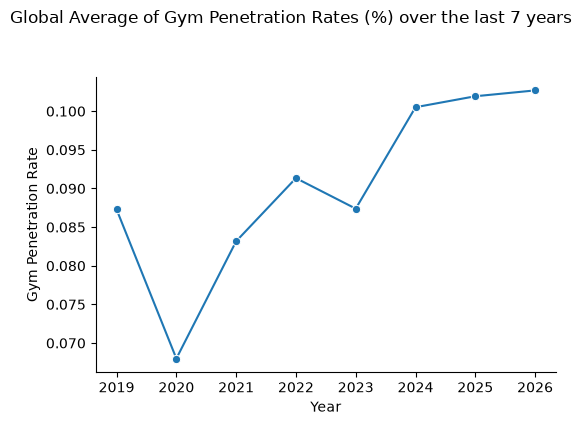

In [19]:
# Global Average of Gym Penetration Rates over the last 7 years

revenue_yearly = (
    df.groupby('year')['gym_penetration_rate']
      .mean()
      .reset_index()
)

g = sns.relplot(
    data=revenue_yearly,
    x='year',
    y='gym_penetration_rate',
    kind='line',
    marker='o',
    height=4,
    aspect=1.4,
)

g.set_axis_labels(
    "Year",
    "Gym Penetration Rate"
)

g.figure.suptitle(
    "Global Average of Gym Penetration Rates (%) over the last 7 years",
    y=1.05,
)

plt.tight_layout()
plt.show()

This plot tells a similar story with the last one. Noting, this there is a possible inference that could directly link gym penetration rates with total revenues earned by health clubs.

From the plots drawn for the gym penetration rates and total revenue, we could see that there has been notable trends observable for our global fitness market indicators. The reason for the drops in their graphs could be explained by recent historic and economic developments. That being said, this observation is not the same for the fitness engagement metrics. From here, a possible conclusion would be that while fitness market indicators continue rise, the fitness engagement metrics, for both fitness participation and insufficient physical activity percentage, could continue to remain stagnant.

#### **Economic Contextualizing**

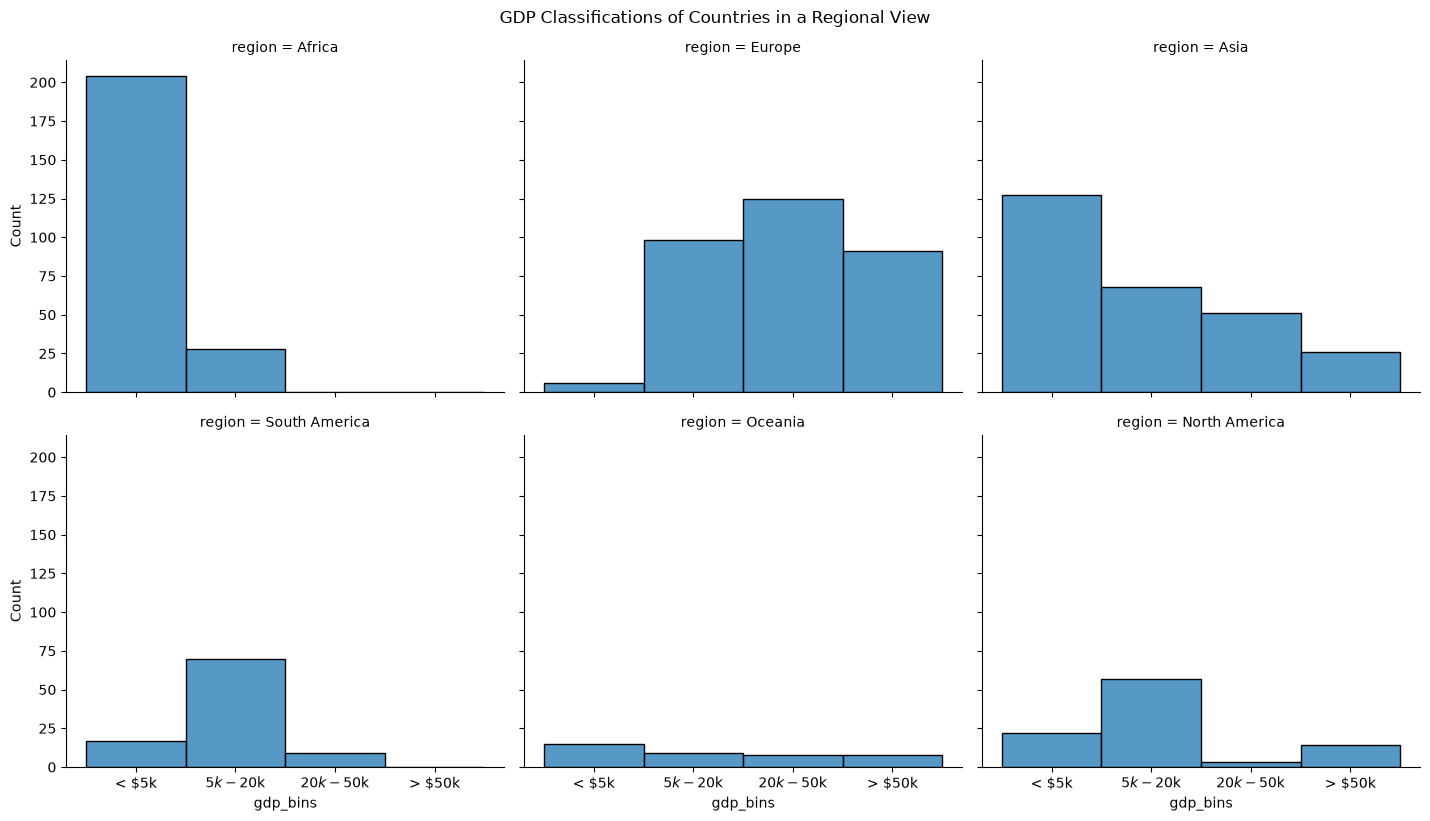

In [20]:
# GDP Classifications of Countries in a Regional View

sns.displot(
    data=df,
    x="gdp_bins",
    col="region",
    bins=15,
    col_wrap=3,
    height=4,
    aspect=1.2
)

plt.suptitle("GDP Classifications of Countries in a Regional View", y=1.02)
plt.show()

From our earlier EDA 2, we have inferred that Africa and South America seem to have a possible correlation between gym prices with their fitness engagement. Looking at the histogram above, it would be possible that due to their more extreme and lower GDP thresholds, making fitness engagement decisions could be less immediate for the population. Unlike in other continents, there seems to be more spread in GDP, which could explain the variations in the correlations we made from earlier. In these continents, it could be possible that decisions are made with less consideration on money.




# **Further Preprocessing**

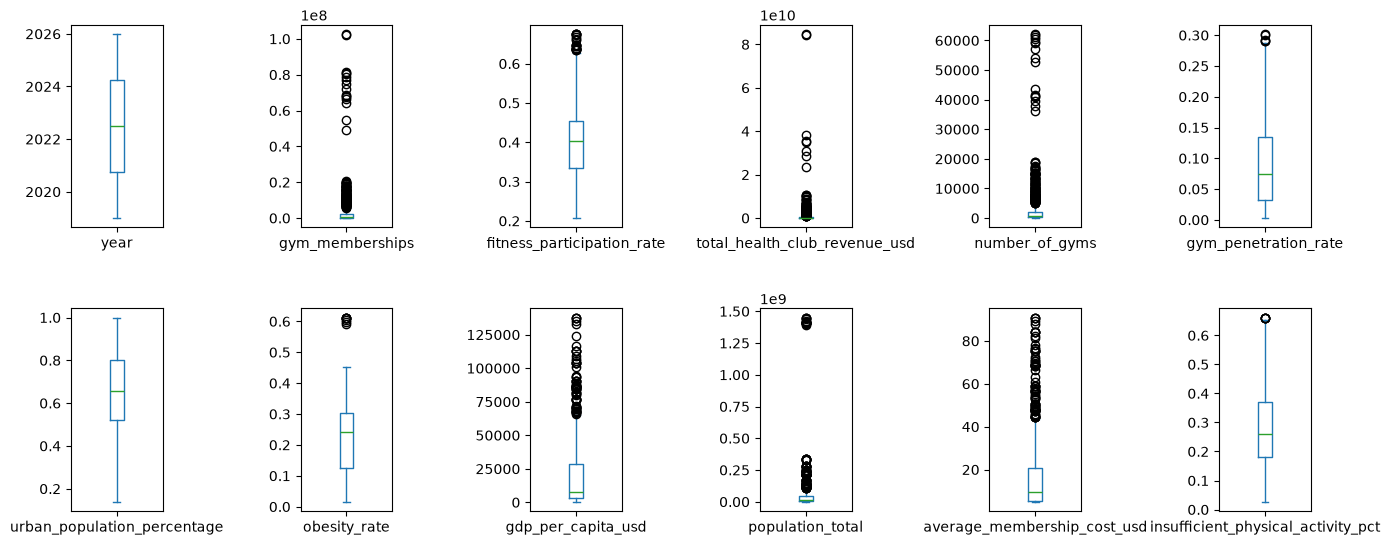

In [21]:
# check distribution
numeric_df = df.select_dtypes(include='number')
numeric_df.plot(
    kind='box', 
    subplots=True, 
    layout=(3, 6), 
    figsize=(16, 10),
    sharex=False, 
    sharey=False
)
plt.subplots_adjust(wspace=1.5, hspace=0.4)
plt.show()

In [22]:
# check for skews
skew = numeric_df.skew()
print(skew)

year                                   0.000000
gym_memberships                        6.706422
fitness_participation_rate             0.342644
total_health_club_revenue_usd         13.690168
number_of_gyms                         5.946490
gym_penetration_rate                   0.814420
urban_population_percentage           -0.403525
obesity_rate                           0.088983
gdp_per_capita_usd                     1.933915
population_total                       6.867378
average_membership_cost_usd            2.032064
insufficient_physical_activity_pct     0.482919
dtype: float64


In [23]:
# apply log transformation for threshold > +1 and < -1
skewed_cols = ['gym_memberships','total_health_club_revenue_usd','number_of_gyms',
               'gdp_per_capita_usd','population_total','average_membership_cost_usd']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

df

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,gdp_bins,cost_bins
19,Angola,2019,Africa,13.610131,0.4832,17.704475,7.136483,0.0252,0.6666,0.0953,7.821915,17.292917,1.791759,0.1763,< $5k,=< $5
20,Angola,2020,Africa,13.266827,0.4875,17.361169,6.893656,0.0173,0.6746,0.0985,7.473271,17.325596,1.791759,0.1751,< $5k,=< $5
21,Angola,2021,Africa,13.587665,0.4917,17.682008,7.135687,0.0231,0.6825,0.1019,7.742796,17.357409,1.791759,0.1741,< $5k,=< $5
22,Angola,2022,Africa,13.896222,0.4958,18.002494,7.320527,0.0304,0.6905,0.1054,8.211514,17.388840,1.801710,0.1733,< $5k,$5 - $10
23,Angola,2023,Africa,13.895936,0.4995,17.990279,7.379632,0.0295,0.6985,0.1054,7.978358,17.419646,1.791759,0.1733,< $5k,=< $5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,Zimbabwe,2022,Africa,12.600072,0.3563,16.694414,6.122493,0.0185,0.3871,0.1243,7.838895,16.592406,1.791759,0.1770,< $5k,=< $5
3560,Zimbabwe,2023,Africa,12.601498,0.3589,16.695839,6.165418,0.0182,0.3929,0.1243,7.694495,16.609177,1.791759,0.1770,< $5k,=< $5
3561,Zimbabwe,2024,Africa,12.704588,0.3616,16.798929,6.232448,0.0198,0.3989,0.1243,7.823327,16.626982,1.791759,0.1770,< $5k,=< $5
3562,Zimbabwe,2025,Africa,12.713231,0.3616,16.807572,6.240276,0.0200,0.3989,0.1243,7.823327,16.626982,1.791759,0.1770,< $5k,=< $5


In [24]:
# one hot encode region
df = pd.get_dummies(df,columns=['region'],dtype=int)
df

,country,year,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,...,average_membership_cost_usd,insufficient_physical_activity_pct,gdp_bins,cost_bins,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
19,Angola,2019,13.610131,0.4832,17.704475,7.136483,0.0252,0.6666,0.0953,7.821915,...,1.791759,0.1763,< $5k,=< $5,1,0,0,0,0,0
20,Angola,2020,13.266827,0.4875,17.361169,6.893656,0.0173,0.6746,0.0985,7.473271,...,1.791759,0.1751,< $5k,=< $5,1,0,0,0,0,0
21,Angola,2021,13.587665,0.4917,17.682008,7.135687,0.0231,0.6825,0.1019,7.742796,...,1.791759,0.1741,< $5k,=< $5,1,0,0,0,0,0
22,Angola,2022,13.896222,0.4958,18.002494,7.320527,0.0304,0.6905,0.1054,8.211514,...,1.801710,0.1733,< $5k,$5 - $10,1,0,0,0,0,0
23,Angola,2023,13.895936,0.4995,17.990279,7.379632,0.0295,0.6985,0.1054,7.978358,...,1.791759,0.1733,< $5k,=< $5,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,Zimbabwe,2022,12.600072,0.3563,16.694414,6.122493,0.0185,0.3871,0.1243,7.838895,...,1.791759,0.1770,< $5k,=< $5,1,0,0,0,0,0
3560,Zimbabwe,2023,12.601498,0.3589,16.695839,6.165418,0.0182,0.3929,0.1243,7.694495,...,1.791759,0.1770,< $5k,=< $5,1,0,0,0,0,0
3561,Zimbabwe,2024,12.704588,0.3616,16.798929,6.232448,0.0198,0.3989,0.1243,7.823327,...,1.791759,0.1770,< $5k,=< $5,1,0,0,0,0,0
3562,Zimbabwe,2025,12.713231,0.3616,16.807572,6.240276,0.0200,0.3989,0.1243,7.823327,...,1.791759,0.1770,< $5k,=< $5,1,0,0,0,0,0


In [25]:
# aggregate through mean per country
df = df.drop(columns=['year'])
df = df.groupby('country',as_index=False).mean(numeric_only=True)
df

,country,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
0,Albania,12.347489,0.409000,17.222148,5.476310,0.095713,0.578912,0.259475,9.057689,14.710338,2.478064,0.240337,0.0,0.0,1.0,0.0,0.0,0.0
1,Algeria,14.236216,0.447263,18.439978,7.591298,0.033900,0.742375,0.237625,8.504744,17.633323,1.883943,0.288125,1.0,0.0,0.0,0.0,0.0,0.0
2,Angola,13.750751,0.495875,17.846585,7.267302,0.026638,0.691562,0.102837,7.861730,17.391834,1.793003,0.174000,1.0,0.0,0.0,0.0,0.0,0.0
3,Argentina,15.248041,0.448437,20.109298,8.250638,0.093188,0.921175,0.352475,9.410444,17.631867,2.465616,0.382900,0.0,0.0,0.0,0.0,0.0,1.0
4,Armenia,12.080786,0.427138,16.580446,5.053324,0.060112,0.655275,0.273537,8.775802,14.910733,2.140696,0.264062,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Uzbekistan,13.994211,0.346550,18.196327,7.181288,0.034638,0.509088,0.276763,7.866721,17.371890,1.882469,0.306875,0.0,1.0,0.0,0.0,0.0,0.0
128,Venezuela,14.254992,0.387738,18.548958,7.573820,0.056125,0.892188,0.228875,8.006007,17.162534,1.961193,0.454412,0.0,0.0,0.0,0.0,0.0,1.0
129,Vietnam,15.103782,0.298500,19.428865,8.172413,0.036862,0.372488,0.019575,8.326490,18.417060,1.987644,0.297250,0.0,1.0,0.0,0.0,0.0,0.0
130,Zambia,12.510616,0.399987,16.604957,6.261342,0.013575,0.447037,0.090487,7.092382,16.822343,1.791759,0.141475,1.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# reformat encoded columns back to int
encoded = ['region_Africa','region_Asia','region_Europe','region_North America','region_Oceania','region_South America']
df[encoded] = df[encoded].astype('int64')
df

,country,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
0,Albania,12.347489,0.409000,17.222148,5.476310,0.095713,0.578912,0.259475,9.057689,14.710338,2.478064,0.240337,0,0,1,0,0,0
1,Algeria,14.236216,0.447263,18.439978,7.591298,0.033900,0.742375,0.237625,8.504744,17.633323,1.883943,0.288125,1,0,0,0,0,0
2,Angola,13.750751,0.495875,17.846585,7.267302,0.026638,0.691562,0.102837,7.861730,17.391834,1.793003,0.174000,1,0,0,0,0,0
3,Argentina,15.248041,0.448437,20.109298,8.250638,0.093188,0.921175,0.352475,9.410444,17.631867,2.465616,0.382900,0,0,0,0,0,1
4,Armenia,12.080786,0.427138,16.580446,5.053324,0.060112,0.655275,0.273537,8.775802,14.910733,2.140696,0.264062,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Uzbekistan,13.994211,0.346550,18.196327,7.181288,0.034638,0.509088,0.276763,7.866721,17.371890,1.882469,0.306875,0,1,0,0,0,0
128,Venezuela,14.254992,0.387738,18.548958,7.573820,0.056125,0.892188,0.228875,8.006007,17.162534,1.961193,0.454412,0,0,0,0,0,1
129,Vietnam,15.103782,0.298500,19.428865,8.172413,0.036862,0.372488,0.019575,8.326490,18.417060,1.987644,0.297250,0,1,0,0,0,0
130,Zambia,12.510616,0.399987,16.604957,6.261342,0.013575,0.447037,0.090487,7.092382,16.822343,1.791759,0.141475,1,0,0,0,0,0


In [27]:
# drop country column
df = df.drop(columns=['country', "region_Africa", "region_Asia", "region_Europe", "region_Oceania", "region_North America", "region_South America"])
df

,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,12.347489,0.409000,17.222148,5.476310,0.095713,0.578912,0.259475,9.057689,14.710338,2.478064,0.240337
1,14.236216,0.447263,18.439978,7.591298,0.033900,0.742375,0.237625,8.504744,17.633323,1.883943,0.288125
2,13.750751,0.495875,17.846585,7.267302,0.026638,0.691562,0.102837,7.861730,17.391834,1.793003,0.174000
3,15.248041,0.448437,20.109298,8.250638,0.093188,0.921175,0.352475,9.410444,17.631867,2.465616,0.382900
4,12.080786,0.427138,16.580446,5.053324,0.060112,0.655275,0.273537,8.775802,14.910733,2.140696,0.264062
...,...,...,...,...,...,...,...,...,...,...,...
127,13.994211,0.346550,18.196327,7.181288,0.034638,0.509088,0.276763,7.866721,17.371890,1.882469,0.306875
128,14.254992,0.387738,18.548958,7.573820,0.056125,0.892188,0.228875,8.006007,17.162534,1.961193,0.454412
129,15.103782,0.298500,19.428865,8.172413,0.036862,0.372488,0.019575,8.326490,18.417060,1.987644,0.297250
130,12.510616,0.399987,16.604957,6.261342,0.013575,0.447037,0.090487,7.092382,16.822343,1.791759,0.141475


In [28]:
# z-standardization
target = [col for col in df.columns if col not in encoded]
df[target] = (df[target] - df[target].mean()) / df[
    target
].std()

df

,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,-0.862997,0.050892,-0.749435,-0.891919,0.081513,-0.282044,0.289344,-0.017815,-1.084240,-0.124139,-0.315307
1,0.342540,0.456871,-0.110094,0.522705,-0.847599,0.486681,0.093461,-0.423479,0.704236,-0.928341,0.041966
2,0.032677,0.972666,-0.421615,0.305998,-0.956763,0.247722,-1.114897,-0.895220,0.556477,-1.051436,-0.811265
3,0.988369,0.469338,0.766271,0.963709,0.043559,1.327534,1.123081,0.240981,0.703346,-0.140989,0.750531
4,-1.033229,0.243338,-1.086318,-1.174836,-0.453596,0.077070,0.415413,-0.224619,-0.961625,-0.580800,-0.137932
...,...,...,...,...,...,...,...,...,...,...,...
127,0.188073,-0.611724,-0.238007,0.248467,-0.836514,-0.610414,0.444325,-0.891559,0.544274,-0.930335,0.182147
128,0.354525,-0.174710,-0.052881,0.511014,-0.513532,1.191213,0.015018,-0.789373,0.416176,-0.823774,1.285179
129,0.896291,-1.121551,0.409055,0.911387,-0.803069,-1.252811,-1.861338,-0.554253,1.183778,-0.787971,0.110187
130,-0.758876,-0.044733,-1.073450,-0.366845,-1.153107,-0.902220,-1.225614,-1.459647,0.208025,-1.053120,-1.054431


In [29]:
# save to csv
df.to_csv('preprocessed_gym_data.csv',index=False)
df

,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,-0.862997,0.050892,-0.749435,-0.891919,0.081513,-0.282044,0.289344,-0.017815,-1.084240,-0.124139,-0.315307
1,0.342540,0.456871,-0.110094,0.522705,-0.847599,0.486681,0.093461,-0.423479,0.704236,-0.928341,0.041966
2,0.032677,0.972666,-0.421615,0.305998,-0.956763,0.247722,-1.114897,-0.895220,0.556477,-1.051436,-0.811265
3,0.988369,0.469338,0.766271,0.963709,0.043559,1.327534,1.123081,0.240981,0.703346,-0.140989,0.750531
4,-1.033229,0.243338,-1.086318,-1.174836,-0.453596,0.077070,0.415413,-0.224619,-0.961625,-0.580800,-0.137932
...,...,...,...,...,...,...,...,...,...,...,...
127,0.188073,-0.611724,-0.238007,0.248467,-0.836514,-0.610414,0.444325,-0.891559,0.544274,-0.930335,0.182147
128,0.354525,-0.174710,-0.052881,0.511014,-0.513532,1.191213,0.015018,-0.789373,0.416176,-0.823774,1.285179
129,0.896291,-1.121551,0.409055,0.911387,-0.803069,-1.252811,-1.861338,-0.554253,1.183778,-0.787971,0.110187
130,-0.758876,-0.044733,-1.073450,-0.366845,-1.153107,-0.902220,-1.225614,-1.459647,0.208025,-1.053120,-1.054431


# **Data Mining**

In this section of the notebook, K-Means clustering will be applied to both reinforce the relationships identified during the exploratory data analysis (EDA) and uncover meaningful groupings of countries based on selected fitness, health, and socioeconomic metrics. These clusters will provide insights into whether countries naturally exhibit similar characteristics beyond the pairwise relationships observed earlier. Additionally, obesity_rate will serve as the primary indicator of negative health outcomes, allowing the analysis to examine how different combinations of variables correspond to varying health profiles across countries.

In [30]:
df.columns.tolist()

['gym_memberships',
 'fitness_participation_rate',
 'total_health_club_revenue_usd',
 'number_of_gyms',
 'gym_penetration_rate',
 'urban_population_percentage',
 'obesity_rate',
 'gdp_per_capita_usd',
 'population_total',
 'average_membership_cost_usd',
 'insufficient_physical_activity_pct']

In [31]:
main_cluster_df = df[
    ['fitness_participation_rate',
    'number_of_gyms',
    'gym_penetration_rate',
    'urban_population_percentage',
    'obesity_rate',
    'gdp_per_capita_usd',
    'average_membership_cost_usd',
    'insufficient_physical_activity_pct']
]

*total_health_club_revenue_usd* was excluded from the main clustering dataframe because the focus of this section is to examine the broader economic characteristics of each region rather than the financial performance of the fitness industry. Meanwhile, *gym_memberships* and *population_total* were also removed, as their relationship is already captured by *gym_penetration_rate*, which represents the proportion of the population holding gym memberships. Retaining only *gym_penetration_rate* avoids redundancy while preserving the relevant information for the clustering analysis.

### **Groupings To be done**:

Fortifying previous discoveries:

1. "fitness_participation_rate", "insufficient_physical_activity_pct", "gym_penetration_rate" - Seeing if fitness engagements metrics are naturally grouped with statistics that relate to people that have gym memberships.

2. "fitness_participation_rate", "insufficient_physical_activity_pct", "gdp_per_capita_usd" - Seeing if fitness engagements metrics are naturally grouped with the economic standings of countries

3. "fitness_participation_rate", "insufficient_physical_activity_pct", "average_membership_cost_usd", "number_of_gyms", "urban_population_percentage" - Seeing if fitness engagements metrics are naturally grouped with the accessbility-driven metrics

### **Linking to actual health outcomes:**:

1. "obesity_rate", "fitness_participation_rate", "insufficient_physical_activity_pct"  - possible establishnment of natural groupings between obesity rates and fitness participations rate (will plot)

2. "obesity_rate", "gym_penetration_rate" - possible establishnment of natural groupings between obesity rates and people that have gym memberships.

3. obesity_rate", "gdp_per_capita_usd" - Seeing if fitness engagements metrics are naturally grouped with the economic standings of countries

4. obesity_rate", "average_membership_cost_usd", "number_of_gyms", "urban_population_percentage" - Seeing if fitness engagements metrics are naturally grouped with the accessbility-driven metrics




The follow sections that would display the relations of the clusters will follow these sequential steps:

1. Determine the optimal number of clusters (k) using the Elbow Method.
2. Apply the K-Means clustering algorithm using the selected value of k.
3. Analyze the relationships of the centroids and interpret the characteristics of each cluster.
4. (If 2 variables only) Visualize the clustering results to identify regional patterns and relationships.

### **Elbow Method**

In [32]:
def compute_sum_of_squares(data, k, iters=50):
    model = KMeans(k=k, start_var=0, end_var=data.shape[1], num_observations=len(data), data=data)
    model.centroids = model.initialize_centroids(data)
    groups = model.train(data, iters)

    wcss = 0
    
    for cluster_id in range(k):
        cluster_points = data[groups == cluster_id]
        centroid = model.centroids.iloc[cluster_id]
        squared_dist = (cluster_points.astype(float) - centroid.astype(float)) ** 2
        wcss += squared_dist.sum().sum()   
    return wcss

#### **Naturally Grouping Fitness Engagement Metrics and Gym Penetraion Rate**

In [33]:
sub_cluster_1 = main_cluster_df[
    ['fitness_participation_rate',
    'insufficient_physical_activity_pct',
    'gym_penetration_rate']
]

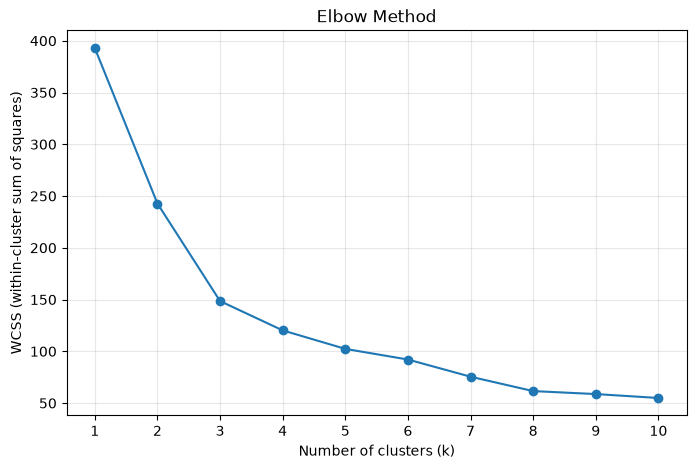

In [34]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_1, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,393.00,NaN,NaN
1,2,242.79,150.21,NaN
2,3,148.54,94.24,55.97
3,4,120.23,28.31,65.93
4,5,102.37,17.86,10.45
5,6,92.08,10.29,7.57
6,7,75.49,16.59,-6.30
7,8,61.61,13.88,2.71
8,9,58.72,2.88,11.00
9,10,54.93,3.79,-0.91


Suggested elbow: k = 4


In [36]:
k = elbow_k

In [37]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_1.shape[1], num_observations=len(sub_cluster_1), data=sub_cluster_1)

kmeans.initialize_centroids(sub_cluster_1)
kmeans.train(sub_cluster_1, iters=50)

0      3
1      2
2      2
3      3
4      2
      ..
127    2
128    1
129    1
130    2
131    2
Length: 132, dtype: int32

In [38]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_1.columns
)

centroids_df.round(2)

,fitness_participation_rate,insufficient_physical_activity_pct,gym_penetration_rate
0,1.40,-0.63,1.44
1,-1.15,1.27,-0.31
2,-0.18,-0.74,-0.86
3,0.13,0.47,0.35


#### **Naturally Grouping Fitness Engagement Metrics and GDP per Capita of Countries**

In [44]:
sub_cluster_2 = main_cluster_df[
    ['fitness_participation_rate',
    'insufficient_physical_activity_pct',
    'gdp_per_capita_usd']
]

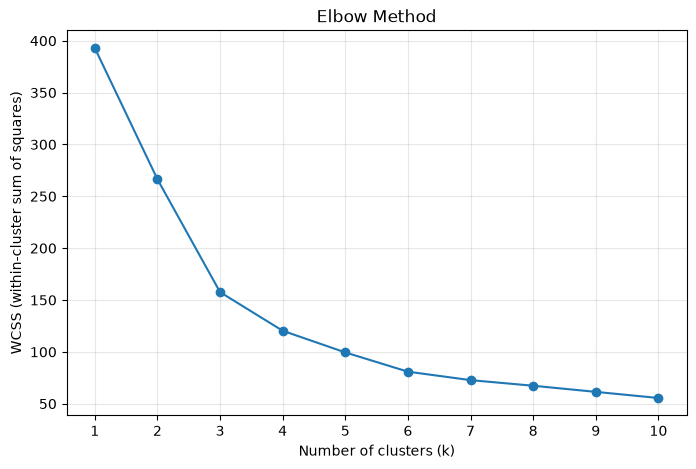

In [45]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_2, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,393.00,NaN,NaN
1,2,266.47,126.53,NaN
2,3,157.61,108.86,17.67
3,4,120.36,37.25,71.61
4,5,99.46,20.90,16.35
5,6,80.90,18.56,2.34
6,7,72.75,8.15,10.41
7,8,67.35,5.41,2.74
8,9,61.43,5.92,-0.51
9,10,55.53,5.90,0.02


Suggested elbow: k = 4


In [49]:
k = 4

In [50]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_2.shape[1], num_observations=len(sub_cluster_2), data=sub_cluster_2)

kmeans.initialize_centroids(sub_cluster_2)
kmeans.train(sub_cluster_2, iters=50)

0      3
1      3
2      2
3      3
4      3
      ..
127    3
128    3
129    3
130    2
131    2
Length: 132, dtype: int32

In [51]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_2.columns
)

centroids_df.round(2)

,fitness_participation_rate,insufficient_physical_activity_pct,gdp_per_capita_usd
0,1.36,-0.63,1.21
1,-1.23,1.58,0.20
2,-0.36,-1.00,-1.25
3,0.01,0.29,0.03


#### **Naturally Grouping Fitness Engagement Metrics and Accessibility-Driven Metrics**

In [52]:
sub_cluster_3 = main_cluster_df[
    ['fitness_participation_rate',
    'insufficient_physical_activity_pct',
    "average_membership_cost_usd", 
    "number_of_gyms", 
    "urban_population_percentage"]
]

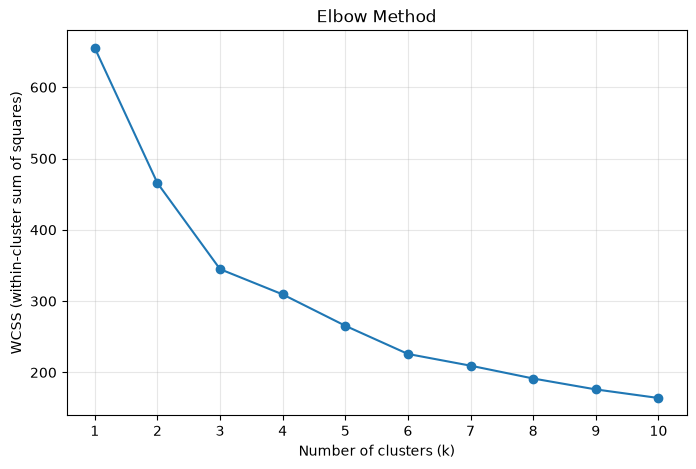

In [53]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_3, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [54]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,655.00,NaN,NaN
1,2,465.57,189.43,NaN
2,3,344.82,120.75,68.68
3,4,309.40,35.42,85.33
4,5,265.41,43.99,-8.57
5,6,225.85,39.55,4.44
6,7,209.43,16.43,23.12
7,8,191.44,17.98,-1.55
8,9,176.13,15.31,2.67
9,10,164.11,12.03,3.28


Suggested elbow: k = 4


In [55]:
k = 4

In [56]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_3.shape[1], num_observations=len(sub_cluster_3), data=sub_cluster_3)

kmeans.initialize_centroids(sub_cluster_3)
kmeans.train(sub_cluster_3, iters=50)

0      2
1      1
2      2
3      3
4      2
      ..
127    1
128    3
129    1
130    2
131    2
Length: 132, dtype: int32

In [57]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_3.columns
)

centroids_df.round(2)

,fitness_participation_rate,insufficient_physical_activity_pct,average_membership_cost_usd,number_of_gyms,urban_population_percentage
0,1.28,-0.50,1.25,0.35,0.84
1,-0.54,0.30,-0.65,0.71,-0.43
2,-0.26,-0.75,-0.69,-0.61,-0.89
3,-0.47,1.25,0.22,-0.02,0.71


#### **Naturally Grouping Obesity Rate and Fitness Engagement Metrics**

In [58]:
sub_cluster_4 = main_cluster_df[
    ['fitness_participation_rate',
    'insufficient_physical_activity_pct',
    "obesity_rate"]
]

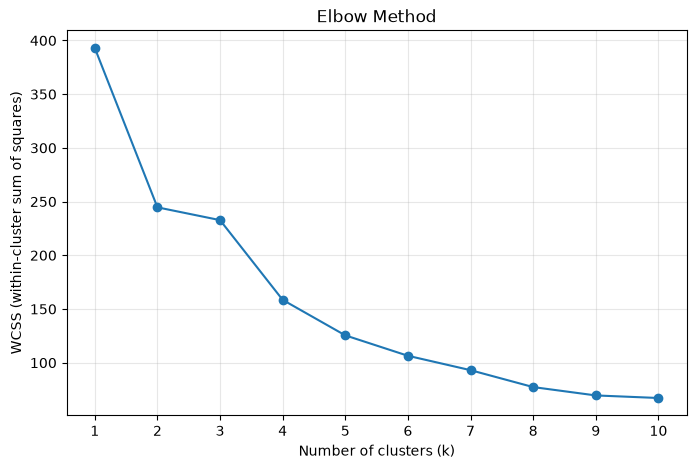

In [59]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_4, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,393.00,NaN,NaN
1,2,244.64,148.36,NaN
2,3,232.74,11.90,136.46
3,4,158.50,74.24,-62.34
4,5,125.46,33.04,41.20
5,6,106.45,19.01,14.03
6,7,93.05,13.40,5.61
7,8,77.31,15.74,-2.34
8,9,69.53,7.78,7.96
9,10,67.15,2.39,5.39


Suggested elbow: k = 3


In [61]:
k = 3

In [62]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_4.shape[1], num_observations=len(sub_cluster_4), data=sub_cluster_4)

kmeans.initialize_centroids(sub_cluster_4)
kmeans.train(sub_cluster_4, iters=50)

0      0
1      0
2      0
3      1
4      0
      ..
127    1
128    1
129    0
130    0
131    0
Length: 132, dtype: int32

In [63]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_4.columns
)

centroids_df.round(2)

,fitness_participation_rate,insufficient_physical_activity_pct,obesity_rate
0,0.42,-0.66,-0.44
1,-0.56,0.97,0.54
2,-1.24,-0.33,2.59


#### **Naturally Grouping Obesity Rate and Gym Penetration Rate**

In [64]:
sub_cluster_5 = main_cluster_df[
    ['gym_penetration_rate',
    "obesity_rate"]
]

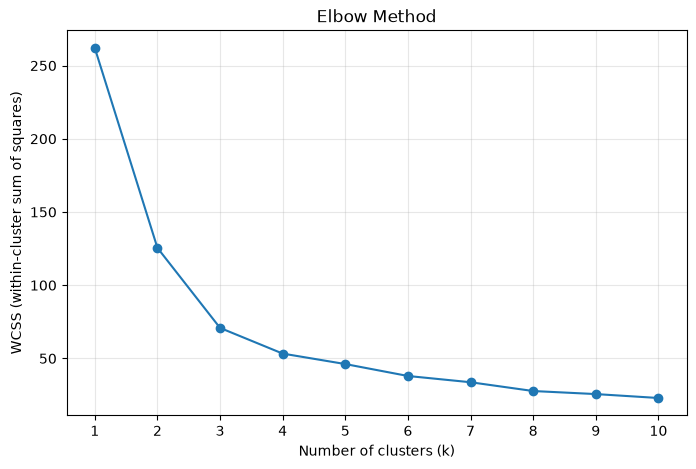

In [66]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_5, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [67]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,262.00,NaN,NaN
1,2,125.50,136.50,NaN
2,3,70.84,54.66,81.84
3,4,53.30,17.54,37.12
4,5,46.14,7.15,10.39
5,6,38.00,8.15,-1.00
6,7,33.73,4.27,3.88
7,8,27.73,6.00,-1.73
8,9,25.64,2.08,3.92
9,10,22.97,2.68,-0.60


Suggested elbow: k = 3


In [68]:
k = 3

In [69]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_5.shape[1], num_observations=len(sub_cluster_5), data=sub_cluster_5)

kmeans.initialize_centroids(sub_cluster_5)
kmeans.train(sub_cluster_5, iters=50)

0      1
1      1
2      2
3      1
4      1
      ..
127    1
128    1
129    2
130    2
131    2
Length: 132, dtype: int32

In [70]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_5.columns
)

centroids_df.round(2)

,gym_penetration_rate,obesity_rate
0,1.59,0.10
1,-0.02,0.71
2,-0.95,-1.14


#### **Naturally Grouping Obesity Rate and GDP per Capita USD**

In [71]:
sub_cluster_6 = main_cluster_df[
    ['gdp_per_capita_usd',
    "obesity_rate"]
]

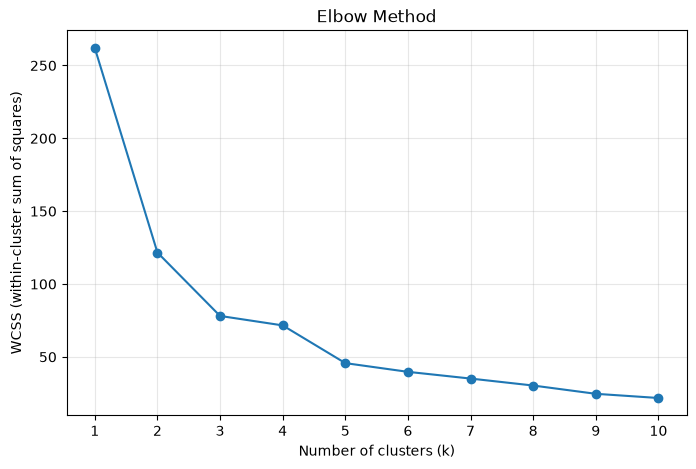

In [72]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_6, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [73]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,262.00,NaN,NaN
1,2,121.62,140.38,NaN
2,3,78.10,43.52,96.86
3,4,71.61,6.49,37.03
4,5,45.72,25.89,-19.40
5,6,39.73,5.99,19.90
6,7,35.12,4.61,1.38
7,8,30.34,4.78,-0.17
8,9,24.66,5.68,-0.90
9,10,21.78,2.88,2.80


Suggested elbow: k = 3


In [74]:
k = 3

In [75]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_6.shape[1], num_observations=len(sub_cluster_6), data=sub_cluster_6)

kmeans.initialize_centroids(sub_cluster_6)
kmeans.train(sub_cluster_6, iters=50)

0      2
1      2
2      1
3      2
4      2
      ..
127    2
128    2
129    1
130    1
131    1
Length: 132, dtype: int32

In [76]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_6.columns
)

centroids_df.round(2)

,gdp_per_capita_usd,obesity_rate
0,1.30,-0.14
1,-1.14,-1.19
2,0.08,0.72


#### **Naturally Grouping Obesity Rate and Accessibility-Driven Metrics**

In [82]:
sub_cluster_7 = main_cluster_df[
    ["average_membership_cost_usd", 
     "number_of_gyms", 
     "urban_population_percentage",
    "obesity_rate"]
]

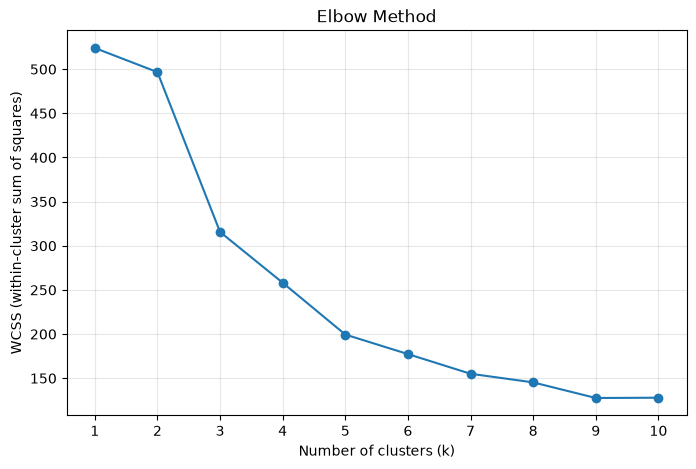

In [83]:
k_range = range(1, 11)
wcss_values = []
for k in k_range:
    wcss = compute_sum_of_squares(sub_cluster_7, k) 
    wcss_values.append(wcss)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

In [84]:
wcss_rounded = [round(x, 2) for x in wcss_values]

decreases = [None] + [
    round(wcss_values[i-1] - wcss_values[i], 2)
    for i in range(1, len(wcss_values))
]

second_diff = [None, None] + [
    round(decreases[i-1] - decreases[i], 2)
    for i in range(2, len(decreases))
]

summary_df = pd.DataFrame({
    "k": range(1, len(wcss_values) + 1),
    "WCSS": wcss_rounded,
    "Decrease": decreases,
    "Change in Decrease": second_diff
})

display(summary_df)

elbow_k = second_diff.index(max(filter(lambda x: x is not None, second_diff))) + 1

print(f"Suggested elbow: k = {elbow_k}")

,k,WCSS,Decrease,Change in Decrease
0,1,524.00,NaN,NaN
1,2,496.66,27.34,NaN
2,3,315.65,181.02,-153.68
3,4,258.16,57.49,123.53
4,5,199.46,58.70,-1.21
5,6,177.35,22.11,36.59
6,7,155.05,22.30,-0.19
7,8,145.27,9.78,12.52
8,9,127.61,17.67,-7.89
9,10,127.92,-0.32,17.99


Suggested elbow: k = 4


In [86]:
k = 4

In [87]:
kmeans = KMeans(k=k, start_var=0, end_var=sub_cluster_7.shape[1], num_observations=len(sub_cluster_7), data=sub_cluster_7)

kmeans.initialize_centroids(sub_cluster_7)
kmeans.train(sub_cluster_7, iters=50)

0      0
1      3
2      2
3      3
4      0
      ..
127    2
128    3
129    2
130    2
131    2
Length: 132, dtype: int32

In [88]:
centroids_df = pd.DataFrame(
    kmeans.centroids,
    columns=sub_cluster_7.columns
)

centroids_df.round(2)

,average_membership_cost_usd,number_of_gyms,urban_population_percentage,obesity_rate
0,0.49,-0.54,0.46,0.54
1,-0.39,-2.83,-2.17,3.41
2,-0.94,-0.15,-1.20,-1.07
3,0.16,1.11,0.51,0.10


# **References & Disclosures**

## **References**

Mishra, A. (2026). *World gym & fitness trends (2000–2026)*. Kaggle. https://www.kaggle.com/datasets/aryanmdev/world-gym-and-fitness-trends-20002026

World Health Organization. (2026). *Physical inactivity*. The Global Health Observatory. https://who-dev5.prgsdev.com/m/data/gho/indicator-metadata-registry/imr-details/3416

## **Disclosure of Generative AI Usage**




During the preparation of this work, the author(s) used Claude AI and Google Gemini for the following purposes:

> *Simplifying Seaborn code documentation for the graphs and illustrations.*

> *Debugging code implementations of the utilized graphs and illustrations.*

> *Debugging code implementation of elbow method algorithm.*


After using this tool/service, the author(s) reviewed and edited the content as needed and take(s) full responsibility for the content of the publication.
